In [2]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Ridge

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import joblib

In [3]:
train_df = pd.read_csv("../data/train_clustered.csv")

train_df.head()

,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,Ease of Online booking,Gate location,...,Arrival Delay in Minutes,satisfaction,Overall_Service_Score,Comfort_Score,Digital_Experience,Total_Delay,Customer_Value,Travel_Experience,Cluster,Passenger_Segment
0,1,0,13.0,1,2,460.0,3.0,4.0,3.0,1.0,...,18.0,0,4.181818,4.333333,3.000000,43.0,1923.636364,3.838384,3,At-Risk Passengers
1,1,1,25.0,0,0,235.0,3.0,2.0,3.0,3.0,...,6.0,0,2.227273,2.333333,3.000000,7.0,523.409091,2.520202,2,Budget Frequent Travelers
2,0,0,26.0,0,0,1142.0,2.0,2.0,2.0,2.0,...,0.0,1,4.181818,4.333333,3.000000,0.0,4775.636364,3.838384,3,At-Risk Passengers
3,0,0,25.0,0,0,562.0,2.0,5.0,5.0,5.0,...,9.0,0,2.500000,3.000000,3.000000,20.0,1405.000000,2.833333,2,Budget Frequent Travelers
4,1,0,61.0,0,0,214.0,3.0,3.0,3.0,3.0,...,0.0,1,3.636364,4.000000,3.666667,0.0,778.181818,3.767677,3,At-Risk Passengers


In [4]:
drop_columns = [

    "Customer_Value",

    "Passenger_Segment",

    "Cluster"

]

X = train_df.drop(columns=drop_columns)

y = train_df["Customer_Value"]

In [5]:
print(X.shape)

print(y.shape)

(103904, 28)
(103904,)


In [6]:
X_train,X_test,y_train,y_test = train_test_split(

    X,

    y,

    test_size=0.2,

    random_state=42

)

print(X_train.shape)

print(X_test.shape)

(83123, 28)
(20781, 28)


In [7]:
linear_model = LinearRegression()

linear_model.fit(

    X_train,

    y_train

)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [8]:
linear_prediction = linear_model.predict(X_test)

In [9]:
mae = mean_absolute_error(

    y_test,

    linear_prediction

)

mse = mean_squared_error(

    y_test,

    linear_prediction

)

rmse = np.sqrt(mse)

r2 = r2_score(

    y_test,

    linear_prediction
)

print("MAE :",mae)

print("MSE :",mse)

print("RMSE :",rmse)

print("R2 :",r2)

MAE : 503.4865341452863
MSE : 516257.1699789901
RMSE : 718.5103826521855
R2 : 0.9636748786632122


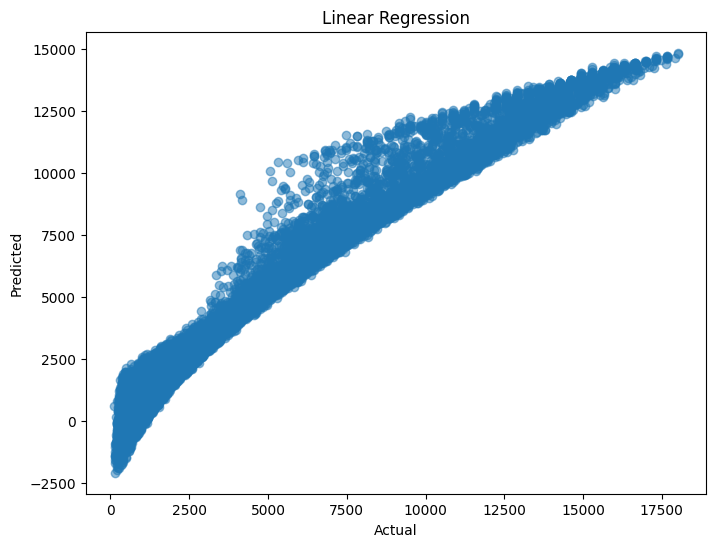

In [10]:
plt.figure(figsize=(8,6))

plt.scatter(

    y_test,

    linear_prediction,

    alpha=0.5

)

plt.xlabel("Actual")

plt.ylabel("Predicted")

plt.title("Linear Regression")

plt.show()

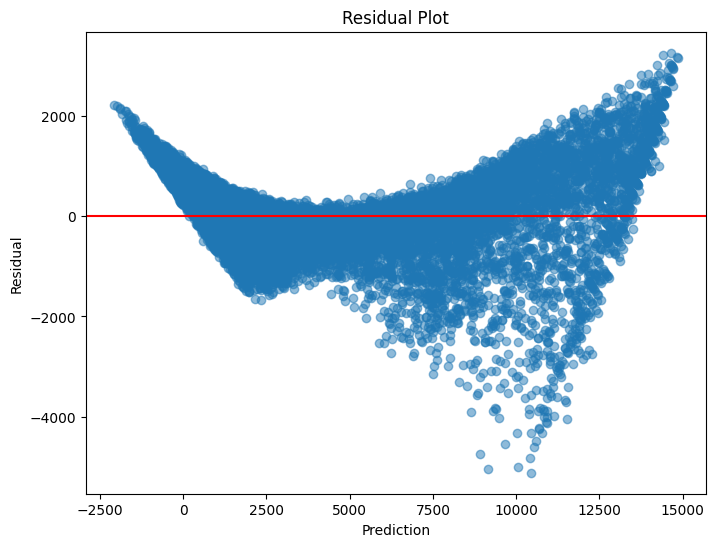

In [11]:
residual = y_test-linear_prediction

plt.figure(figsize=(8,6))

plt.scatter(

    linear_prediction,

    residual,

    alpha=0.5

)

plt.axhline(

    0,

    color="red"

)

plt.xlabel("Prediction")

plt.ylabel("Residual")

plt.title("Residual Plot")

plt.show()

In [12]:
ridge = Ridge(

    alpha=1.0

)

ridge.fit(

    X_train,

    y_train
)

,alpha,1.0
,fit_intercept,True
,copy_X,True
,max_iter,None
,tol,0.0001
,solver,'auto'
,positive,False
,random_state,None


In [13]:
ridge_prediction = ridge.predict(

    X_test
)

In [14]:
ridge_mae = mean_absolute_error(

    y_test,

    ridge_prediction

)

ridge_mse = mean_squared_error(

    y_test,

    ridge_prediction

)

ridge_rmse = np.sqrt(

    ridge_mse

)

ridge_r2 = r2_score(

    y_test,

    ridge_prediction
)

print(ridge_mae)

print(ridge_rmse)

print(ridge_r2)

503.4854579515057
718.5103696564506
0.9636748799772409


In [15]:
comparison = pd.DataFrame({

    "Model":[

        "Linear Regression",

        "Ridge Regression"

    ],

    "MAE":[

        mae,

        ridge_mae

    ],

    "RMSE":[

        rmse,

        ridge_rmse

    ],

    "R2 Score":[

        r2,

        ridge_r2

    ]

})

comparison

,Model,MAE,RMSE,R2 Score
0,Linear Regression,503.486534,718.510383,0.963675
1,Ridge Regression,503.485458,718.510370,0.963675


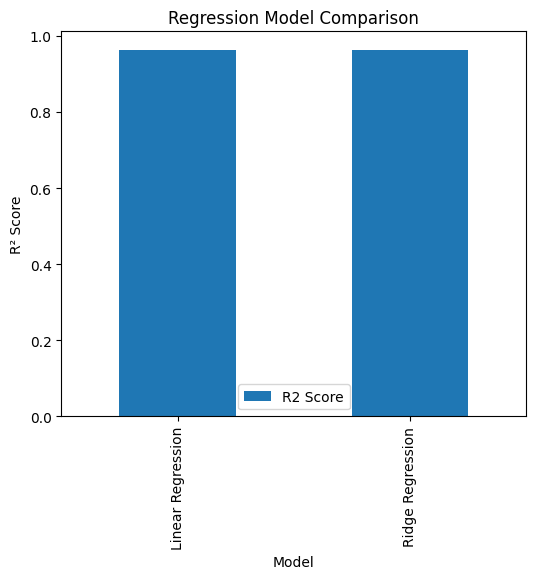

In [16]:
comparison.plot(

    x="Model",

    y="R2 Score",

    kind="bar",

    figsize=(6,5)

)

plt.title("Regression Model Comparison")

plt.ylabel("R² Score")

plt.show()

In [17]:
importance = pd.DataFrame({

    "Feature":X.columns,

    "Coefficient":linear_model.coef_

})

importance = importance.sort_values(

    by="Coefficient",

    key=abs,

    ascending=False

)

importance

,Feature,Coefficient
22,satisfaction,202.955381
4,Class,128.617536
18,Inflight service,126.711098
16,Baggage handling,126.295147
1,Customer Type,113.712548
11,Online boarding,110.485918
17,Checkin service,104.758665
15,Leg room service,102.469866
14,On-board service,102.394816
23,Overall_Service_Score,90.768329


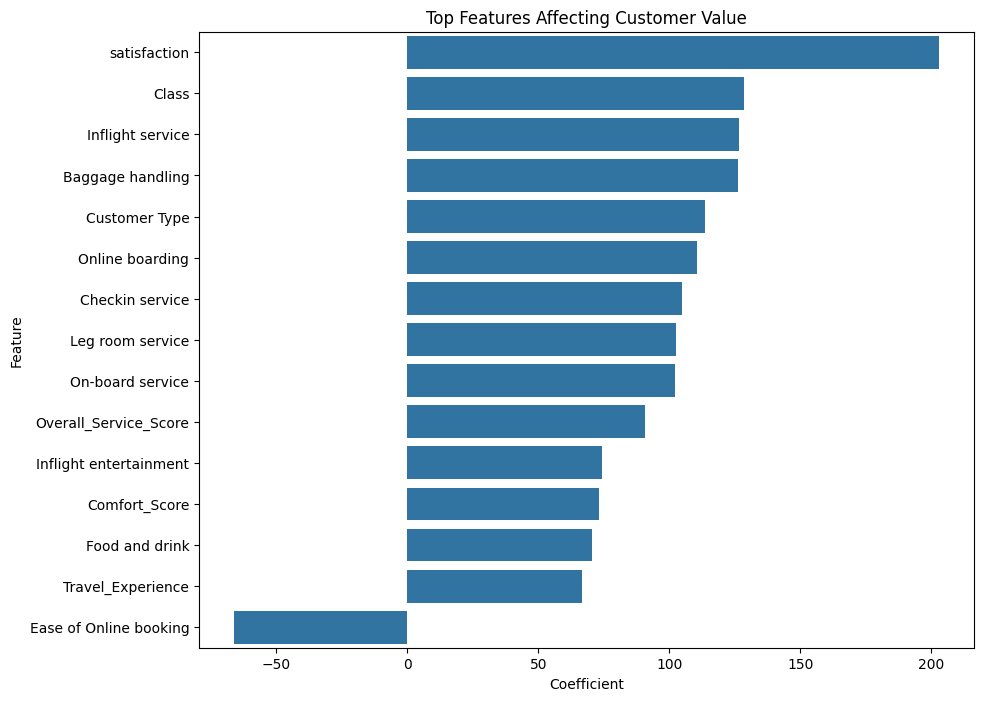

In [18]:
plt.figure(figsize=(10,8))

sns.barplot(

    data=importance.head(15),

    x="Coefficient",

    y="Feature"

)

plt.title("Top Features Affecting Customer Value")

plt.show()

In [19]:
joblib.dump(

    linear_model,

    "../models/linear_regression.pkl"

)

joblib.dump(

    ridge,

    "../models/ridge_regression.pkl"

)

['../models/ridge_regression.pkl']

In [20]:
comparison.to_csv(

    "../reports/regression_results.csv",

    index=False

)

importance.to_csv(

    "../reports/regression_feature_importance.csv",

    index=False
)